In [1]:
# ============================================================
# E4 Sleep Staging v4 — BRANCHED architecture
# BVP  (waveform, 32Hz, 960 samples/epoch)  -> small CNN
# HR   (trend,   1Hz,   30  samples/epoch)  -> MLP
# TEMP (trend,   4Hz,   120 samples/epoch)  -> MLP
# Fusion -> per-epoch embedding -> inter-epoch BiMamba (context) -> classifier
#
# Changes vs v3:
#   - No artifact weighting borrowed from EEG (conceptually wrong,
#     EEG-noisy != E4-noisy). Uses E4's own quality mask instead
#     (flat/NaN detection done at preprocessing time).
#   - Much smaller model (single-resolution branches, not triple-CNN)
#     since HR/TEMP are trends, not multi-frequency waveforms.
#   - No intra-epoch BiMamba (each epoch already collapses to one
#     embedding per modality before fusion) - only inter-epoch
#     (context-window) BiMamba is kept, since THAT'S where the
#     temporal sleep-stage information actually lives for these signals.
#   - SupCon lambda defaults to 0 (set >0 only if you verify it helps;
#     v3 logs showed it plateauing almost immediately and doing
#     essentially nothing useful for this modality).
# ============================================================

import os
import csv
import math
import random
import warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score
warnings.filterwarnings('ignore')

# ============================================================
# PATHS & CONFIG
# ============================================================
E4_PATH   = r"D:\22\AA\preprocess\preprocessed_E4_v4_branched"
EVAL_PATH = r"D:\22\AA\evaluation\e4_v4_branched"
os.makedirs(EVAL_PATH, exist_ok=True)

LABEL_NAMES = ["Wake", "N1", "N2", "N3", "REM"]
CONTEXT     = 7
WINDOW      = 2 * CONTEXT + 1
N_EPOCHS    = 30
BATCH_SIZE  = 64
SEEDS       = [42, 123, 256, 789, 999]

D_MODEL     = 64          # much smaller than the 128 used for EEG
D_STATE     = 16
DROPOUT     = 0.5         # heavier reg — small-signal, easy to overfit
SUPCON_LAMBDA = 0.0        # off by default; flip on only if you A/B it
SUPCON_TEMP   = 0.1
PROJ_DIM      = 32

BVP_SAMPLES  = 1920  # 64Hz x 30s (native BVP rate, confirmed via channels.tsv)
HR_SAMPLES   = 30    # 1Hz  x 30s
TEMP_SAMPLES = 120   # 4Hz  x 30s

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device       : {device}")
print(f"Architecture : BVP-CNN + HR-MLP + TEMP-MLP -> fusion -> inter-epoch BiMamba")
print(f"D_MODEL      : {D_MODEL}  (v3 used 128)")
print(f"SupCon       : {'ON' if SUPCON_LAMBDA > 0 else 'OFF'}")
print(f"Output       : {EVAL_PATH}")

TRAIN_SUBS = np.load(os.path.join(E4_PATH, '_train_subs.npy'), allow_pickle=True).tolist()
TEST_SUBS  = np.load(os.path.join(E4_PATH, '_test_subs.npy'),  allow_pickle=True).tolist()
print(f"Train: {len(TRAIN_SUBS)}  Test: {len(TEST_SUBS)}")


# ============================================================
# DATASET
# ============================================================
class E4BranchedDataset(Dataset):
    def __init__(self, subject_list, data_path, context=CONTEXT):
        self.context = context
        self.data  = []
        self.index = []
        label_counter = Counter()

        for sub in subject_list:
            fp = os.path.join(data_path, f"{sub}.npz")
            if not os.path.exists(fp):
                continue
            with np.load(fp) as d:
                bvp   = d['bvp'].astype(np.float32)     # (N,1,960)
                hr    = d['hr'].astype(np.float32)       # (N,1,30)
                temp  = d['temp'].astype(np.float32)     # (N,1,120)
                labels = d['labels'].copy()
                quality = d['quality'].astype(np.float32) if 'quality' in d else np.ones(len(labels), np.float32)

            n = len(labels)
            sub_idx = len(self.data)
            self.data.append((bvp, hr, temp, labels, quality))

            for i in range(n):
                self.index.append((sub_idx, i, n, float(quality[i])))
                label_counter[int(labels[i])] += 1

        self.label_counts = np.array([label_counter[i] for i in range(5)], dtype=np.float32)
        total = len(self.index)
        ram = sum(b.nbytes + h.nbytes + t.nbytes for b, h, t, _, _ in self.data) / 1e9
        print(f"  Samples : {total:,}   RAM: {ram:.2f} GB")

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sub_idx, center_i, n, weight = self.index[idx]
        bvp, hr, temp, labels, _ = self.data[sub_idx]

        bvp_w, hr_w, temp_w = [], [], []
        for offset in range(-self.context, self.context + 1):
            ei = max(0, min(n - 1, center_i + offset))
            bvp_w.append(bvp[ei])
            hr_w.append(hr[ei])
            temp_w.append(temp[ei])

        x_bvp  = np.stack(bvp_w,  axis=0)   # (W,1,960)
        x_hr   = np.stack(hr_w,   axis=0)   # (W,1,30)
        x_temp = np.stack(temp_w, axis=0)   # (W,1,120)
        y = int(labels[center_i])
        return (
            torch.FloatTensor(x_bvp),
            torch.FloatTensor(x_hr),
            torch.FloatTensor(x_temp),
            torch.tensor(y, dtype=torch.long),
            torch.tensor(weight, dtype=torch.float32),
        )


print("\nBuilding datasets...")
train_ds = E4BranchedDataset(TRAIN_SUBS, E4_PATH)
test_ds  = E4BranchedDataset(TEST_SUBS,  E4_PATH)
print("Datasets ready.")


# ============================================================
# MODEL
# ============================================================
class BVPCnnBranch(nn.Module):
    """Single-resolution CNN — BVP is a real waveform (pulse shape),
    but only ONE dominant frequency band matters, so no need for the
    triple-kernel multi-resolution design used for EEG."""
    def __init__(self, out_dim, dropout=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=15, stride=2, padding=7),
            nn.BatchNorm1d(16), nn.GELU(), nn.MaxPool1d(4, 4), nn.Dropout(dropout),
            nn.Conv1d(16, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32), nn.GELU(), nn.MaxPool1d(4, 4), nn.Dropout(dropout),
            nn.AdaptiveAvgPool1d(1),
        )
        self.proj = nn.Linear(32, out_dim)

    def forward(self, x):          # x: (B, 1, 960)
        f = self.net(x).squeeze(-1)
        return self.proj(f)


class TrendMlpBranch(nn.Module):
    """HR / TEMP are slow physiological trends, not waveforms.
    A small MLP over the raw (short) sequence is enough — no need
    for conv layers built for waveform-shape extraction."""
    def __init__(self, in_len, out_dim, hidden=32, dropout=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_len, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, x):          # x: (B, 1, L)
        return self.net(x.squeeze(1))


class MambaBlock(nn.Module):
    def __init__(self, d_model=D_MODEL, d_state=D_STATE, d_conv=4, expand=2, dropout=DROPOUT):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        self.d_inner = d_model * expand

        self.in_proj = nn.Linear(d_model, self.d_inner * 2, bias=False)
        self.conv1d  = nn.Conv1d(self.d_inner, self.d_inner, kernel_size=d_conv,
                                  padding=d_conv - 1, groups=self.d_inner, bias=True)
        self.x_proj  = nn.Linear(self.d_inner, d_state * 2 + 1, bias=False)
        self.dt_proj = nn.Linear(1, self.d_inner, bias=True)

        A = torch.arange(1, d_state + 1, dtype=torch.float32).unsqueeze(0)
        self.A_log = nn.Parameter(torch.log(A.expand(self.d_inner, -1)))
        self.D     = nn.Parameter(torch.ones(self.d_inner))

        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)
        self.norm     = nn.LayerNorm(d_model)
        self.dropout  = nn.Dropout(dropout)

    def ssm_scan(self, x, A, B, C, D):
        B_size, L, d = x.shape
        h = torch.zeros(B_size, d, self.d_state, device=x.device, dtype=x.dtype)
        ys = []
        for i in range(L):
            xi = x[:, i, :]
            h = h * A.unsqueeze(0) + xi.unsqueeze(-1) * B[:, i, :].unsqueeze(1)
            y = (h * C[:, i, :].unsqueeze(1)).sum(-1) + D * xi
            ys.append(y)
        return torch.stack(ys, dim=1)

    def forward(self, x):
        residual = x
        Bb, L, _ = x.shape
        xz = self.in_proj(x)
        x_, z = xz.chunk(2, dim=-1)
        x_ = F.silu(self.conv1d(x_.transpose(1, 2))[:, :, :L].transpose(1, 2))
        ssm_p = self.x_proj(x_)
        dt_r, Bp, Cp = ssm_p.split([1, self.d_state, self.d_state], dim=-1)
        dt = F.softplus(self.dt_proj(dt_r))
        A = -torch.exp(self.A_log)
        A_disc = torch.exp(dt.unsqueeze(-1) * A.unsqueeze(0).unsqueeze(0)).mean(1).mean(0)
        y = self.ssm_scan(x_, A_disc, Bp, Cp, self.D)
        y = self.out_proj(self.dropout(y * F.silu(z)))
        return self.norm(y + residual)


class BiMambaBlock(nn.Module):
    def __init__(self, d_model=D_MODEL, d_state=D_STATE, dropout=DROPOUT):
        super().__init__()
        self.fwd = MambaBlock(d_model, d_state, dropout=dropout)
        self.bwd = MambaBlock(d_model, d_state, dropout=dropout)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        fwd = self.fwd(x)
        bwd = torch.flip(self.bwd(torch.flip(x, [1])), [1])
        return self.norm(fwd + bwd)


class E4BranchedNet(nn.Module):
    def __init__(self, d_model=D_MODEL, d_state=D_STATE, n_layers=2, dropout=DROPOUT,
                 n_classes=5, context=CONTEXT, proj_dim=PROJ_DIM):
        super().__init__()
        self.context = context
        self.d_model = d_model
        third = d_model // 3

        self.bvp_branch  = BVPCnnBranch(third, dropout)
        self.hr_branch   = TrendMlpBranch(HR_SAMPLES,   third, dropout=dropout)
        self.temp_branch = TrendMlpBranch(TEMP_SAMPLES, third, dropout=dropout)

        self.fuse = nn.Sequential(
            nn.Linear(third * 3, d_model), nn.GELU(), nn.Dropout(dropout),
        )

        self.inter_pos     = nn.Parameter(torch.randn(1, WINDOW, d_model) * 0.01)
        self.inter_bimamba = nn.Sequential(*[BiMambaBlock(d_model, d_state, dropout) for _ in range(n_layers)])

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model), nn.Linear(d_model, 48), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(48, n_classes),
        )
        self.projector = nn.Sequential(
            nn.LayerNorm(d_model), nn.Linear(d_model, d_model), nn.GELU(),
            nn.Linear(d_model, proj_dim),
        )

    def forward(self, x_bvp, x_hr, x_temp):
        B, W = x_bvp.shape[0], x_bvp.shape[1]

        f_bvp  = self.bvp_branch(x_bvp.view(B * W, *x_bvp.shape[2:]))
        f_hr   = self.hr_branch(x_hr.view(B * W, *x_hr.shape[2:]))
        f_temp = self.temp_branch(x_temp.view(B * W, *x_temp.shape[2:]))

        fused = self.fuse(torch.cat([f_bvp, f_hr, f_temp], dim=1))   # (B*W, d_model)
        fused = fused.view(B, W, self.d_model)

        inter  = self.inter_bimamba(fused + self.inter_pos)
        center = inter[:, self.context, :]

        logits = self.classifier(center)
        proj   = F.normalize(self.projector(center), dim=1)
        return logits, proj


# ============================================================
# LOSS
# ============================================================
class SupConLoss(nn.Module):
    def __init__(self, temperature=SUPCON_TEMP):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        B = features.shape[0]
        dev = features.device
        sim = torch.matmul(features, features.T) / self.temperature
        sim = sim - sim.max(dim=1, keepdim=True)[0].detach()
        pos = (labels.unsqueeze(1) == labels.unsqueeze(0)).float()
        sm = torch.eye(B, device=dev)
        pos = pos - sm
        denom = torch.exp(sim) * (1 - sm)
        lp = sim - torch.log(denom.sum(1, keepdim=True) + 1e-8)
        n_pos = pos.sum(1)
        am = (n_pos > 0).float()
        loss = -(pos * lp).sum(1) / (n_pos + 1e-8)
        return (loss * am).sum() / (am.sum() + 1e-8)


supcon_loss = SupConLoss()
cw_np = train_ds.label_counts.sum() / (5 * train_ds.label_counts)
cw = torch.FloatTensor(cw_np).to(device)
print(f"\nClass weights: " + " | ".join(f"{n}:{w:.2f}" for n, w in zip(LABEL_NAMES, cw_np)))


def combined_loss(logits, proj, labels, weights):
    ce = nn.CrossEntropyLoss(weight=cw, reduction='none')(logits, labels)
    wce = ce * weights
    valid = weights > 0
    l_ce = wce[valid].mean() if valid.sum() > 0 else wce.mean()
    if SUPCON_LAMBDA > 0:
        l_sc = supcon_loss(proj, labels)
        return l_ce + SUPCON_LAMBDA * l_sc, l_ce.item(), l_sc.item()
    return l_ce, l_ce.item(), 0.0


# ============================================================
# TRAIN / EVAL HELPERS
# ============================================================
def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    tl = tc = ts = 0
    preds, labs = [], []
    for x_bvp, x_hr, x_temp, y, w in loader:
        x_bvp, x_hr, x_temp = x_bvp.to(device), x_hr.to(device), x_temp.to(device)
        y, w = y.to(device), w.to(device)
        optimizer.zero_grad()
        logits, proj = model(x_bvp, x_hr, x_temp)
        loss, lc, ls = combined_loss(logits, proj, y, w)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        tl += loss.item(); tc += lc; ts += ls
        preds.extend(logits.argmax(1).cpu().numpy())
        labs.extend(y.cpu().numpy())
    n = len(loader)
    return (tl/n, tc/n, ts/n, accuracy_score(labs, preds),
            f1_score(labs, preds, average='macro', zero_division=0))


def evaluate(model, loader):
    model.eval()
    preds, labs = [], []
    with torch.no_grad():
        for x_bvp, x_hr, x_temp, y, w in loader:
            logits, _ = model(x_bvp.to(device), x_hr.to(device), x_temp.to(device))
            preds.extend(logits.argmax(1).cpu().numpy())
            labs.extend(y.numpy())
    preds, labs = np.array(preds), np.array(labs)
    acc = accuracy_score(labs, preds)
    f1 = f1_score(labs, preds, average='macro', zero_division=0)
    kappa = cohen_kappa_score(labs, preds)
    per = f1_score(labs, preds, average=None, zero_division=0)
    return acc, f1, kappa, per, preds, labs


# ============================================================
# CSV
# ============================================================
csv_summary = os.path.join(EVAL_PATH, "summary.csv")
fields = ["seed", "acc", "f1_macro", "kappa", "f1_Wake", "f1_N1", "f1_N2", "f1_N3", "f1_REM"]
with open(csv_summary, 'w', newline='') as f:
    csv.DictWriter(f, fields).writeheader()


# ============================================================
# 5-SEED TRAINING
# ============================================================
all_results = []
for seed_idx, seed in enumerate(SEEDS):
    print(f"\n{'='*60}\nSEED {seed}  ({seed_idx+1}/{len(SEEDS)})\n{'='*60}")
    set_seed(seed)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=0, generator=torch.Generator().manual_seed(seed))
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = E4BranchedNet().to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"  Parameters: {n_params:,}  (v3 had ~991K)")

    optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=5e-4, betas=(0.9, 0.98), eps=1e-9)
    total_steps = N_EPOCHS * len(train_loader)
    warmup_steps = int(0.05 * total_steps)

    def lr_fn(step):
        if step < warmup_steps:
            return step / max(warmup_steps, 1)
        t = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return 0.5 * (1 + math.cos(math.pi * t))

    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_fn)

    best_f1, best_path = 0.0, os.path.join(EVAL_PATH, f"best_seed{seed}.pt")

    for epoch in range(1, N_EPOCHS + 1):
        tl, tc, ts, tr_acc, tr_f1 = train_epoch(model, train_loader, optimizer, scheduler)
        acc, f1, kap, per, _, _ = evaluate(model, test_loader)

        saved = ""
        if f1 > best_f1:
            best_f1 = f1
            torch.save(model.state_dict(), best_path)
            saved = " <- BEST"

        lr = optimizer.param_groups[0]['lr']
        print(f"  Ep[{epoch:02d}/{N_EPOCHS}] Loss:{tl:.3f} TrAcc:{tr_acc:.3f} "
              f"ValAcc:{acc:.3f} F1:{f1:.3f} k:{kap:.3f} LR:{lr:.2e}{saved}")

        if epoch % 10 == 0:
            print("    Per-class: " + " | ".join(f"{LABEL_NAMES[i]}={per[i]:.3f}" for i in range(5)))

    model.load_state_dict(torch.load(best_path, map_location=device))
    fin_acc, fin_f1, fin_kap, fin_per, _, _ = evaluate(model, test_loader)

    print(f"\n  Seed {seed} FINAL: Acc={fin_acc*100:.2f}%  F1={fin_f1:.4f}  Kappa={fin_kap:.4f}")
    for i, name in enumerate(LABEL_NAMES):
        print(f"    {name:6s}: {fin_per[i]:.4f}")

    all_results.append({'seed': seed, 'acc': fin_acc, 'f1': fin_f1, 'kappa': fin_kap, 'per_cls': fin_per})

    with open(csv_summary, 'a', newline='') as f_:
        csv.DictWriter(f_, fields).writerow({
            "seed": seed, "acc": round(fin_acc, 4), "f1_macro": round(fin_f1, 4),
            "kappa": round(fin_kap, 4),
            "f1_Wake": round(fin_per[0], 4), "f1_N1": round(fin_per[1], 4),
            "f1_N2": round(fin_per[2], 4), "f1_N3": round(fin_per[3], 4), "f1_REM": round(fin_per[4], 4),
        })

# ============================================================
# FINAL REPORT
# ============================================================
accs = np.array([r['acc'] for r in all_results]) * 100
f1s = np.array([r['f1'] for r in all_results])
kappas = np.array([r['kappa'] for r in all_results])

print(f"\n{'='*60}\n5-SEED FINAL REPORT — E4 v4 BRANCHED (BVP-CNN + HR/TEMP-MLP)\n{'='*60}")
print(f"Accuracy : {accs.mean():.2f} ± {accs.std():.2f}%")
print(f"Macro F1 : {f1s.mean():.4f} ± {f1s.std():.4f}")
print(f"Kappa    : {kappas.mean():.4f} ± {kappas.std():.4f}")
print(f"\nCompare against v3 (uniform 64Hz, unbranched, EEG-artifact-weighted):")
print(f"  v3: Acc=48.75±1.40%  F1=0.4624±0.0053  Kappa=0.2988±0.0075")
print(f"  v4: Acc={accs.mean():.2f}±{accs.std():.2f}%  F1={f1s.mean():.4f}±{f1s.std():.4f}  Kappa={kappas.mean():.4f}±{kappas.std():.4f}")
print(f"\nSummary saved: {csv_summary}")

Device       : cuda
Architecture : BVP-CNN + HR-MLP + TEMP-MLP -> fusion -> inter-epoch BiMamba
D_MODEL      : 64  (v3 used 128)
SupCon       : OFF
Output       : D:\22\AA\evaluation\e4_v4_branched
Train: 73  Test: 19

Building datasets...
  Samples : 68,857   RAM: 0.57 GB
  Samples : 18,899   RAM: 0.16 GB
Datasets ready.

Class weights: Wake:1.84 | N1:3.14 | N2:0.45 | N3:1.00 | REM:1.12

SEED 42  (1/5)
  Parameters: 154,084  (v3 had ~991K)
  Ep[01/30] Loss:1.543 TrAcc:0.309 ValAcc:0.379 F1:0.319 k:0.158 LR:3.33e-04 <- BEST
  Ep[02/30] Loss:1.394 TrAcc:0.366 ValAcc:0.373 F1:0.359 k:0.188 LR:5.00e-04 <- BEST
  Ep[03/30] Loss:1.325 TrAcc:0.383 ValAcc:0.374 F1:0.365 k:0.204 LR:4.97e-04 <- BEST
  Ep[04/30] Loss:1.287 TrAcc:0.405 ValAcc:0.398 F1:0.388 k:0.229 LR:4.91e-04 <- BEST
  Ep[05/30] Loss:1.270 TrAcc:0.410 ValAcc:0.416 F1:0.415 k:0.257 LR:4.82e-04 <- BEST
  Ep[06/30] Loss:1.245 TrAcc:0.421 ValAcc:0.413 F1:0.412 k:0.250 LR:4.70e-04
  Ep[07/30] Loss:1.230 TrAcc:0.424 ValAcc:0.387 F1:0.

Device: cuda
Test subjects: 19

Building test dataset...
  Samples: 18,899
Ready.
  Seed 42: individual test acc = 42.58%
  Seed 123: individual test acc = 43.57%
  Seed 256: individual test acc = 43.09%
  Seed 789: individual test acc = 43.38%
  Seed 999: individual test acc = 44.17%

Loaded 5/5 seed models for ensembling.

ENSEMBLE RESULT (5-seed soft voting) — E4 v4 branched
Accuracy    : 43.72%
Macro F1    : 0.4480
Cohen Kappa : 0.2767

Per-class F1:
  Wake  : 0.5819  █████████
  N1    : 0.3246  █████
  N2    : 0.3898  ██████
  N3    : 0.4830  ███████
  REM   : 0.4605  ███████

COMPARISON
Model                                       Acc%      F1   Kappa
--------------------------------------------------------------
Zmax EEG (BiT-MamSleep ens., 5-seed)       84.01  0.8016      --
E4 v4 branched (this, 5-seed ensemble)     43.72  0.4480  0.2767

Confusion matrix saved: D:\22\AA\evaluation\e4_v4_branched\ensemble_confusion_matrix.png
Ensemble predictions saved: D:\22\AA\evaluation\e4_v

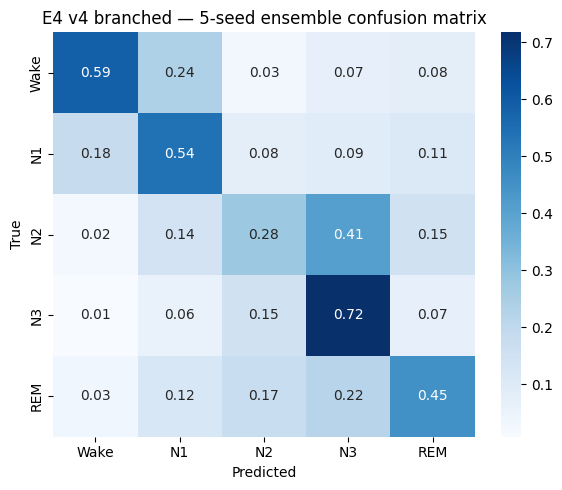

In [2]:
# ============================================================
# E4 v4 Branched — 5-SEED ENSEMBLE EVALUATION
# Loads all 5 best_seed{seed}.pt checkpoints, does soft-voting
# (averaged softmax probabilities) on the test set.
# Run this AFTER 02_train_e4_v4_branched.py has produced the
# best_seed42.pt ... best_seed999.pt files in EVAL_PATH.
# ============================================================

import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# PATHS & CONFIG — must match 02_train_e4_v4_branched.py
# ============================================================
E4_PATH   = r"D:\22\AA\preprocess\preprocessed_E4_v4_branched"
EVAL_PATH = r"D:\22\AA\evaluation\e4_v4_branched"

LABEL_NAMES = ["Wake", "N1", "N2", "N3", "REM"]
CONTEXT     = 7
WINDOW      = 2 * CONTEXT + 1
BATCH_SIZE  = 64
SEEDS       = [42, 123, 256, 789, 999]

D_MODEL   = 64
D_STATE   = 16
DROPOUT   = 0.5      # dropout is disabled in eval() anyway, value doesn't matter here
PROJ_DIM  = 32

BVP_SAMPLES  = 1920
HR_SAMPLES   = 30
TEMP_SAMPLES = 120

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

TEST_SUBS = np.load(os.path.join(E4_PATH, '_test_subs.npy'), allow_pickle=True).tolist()
print(f"Test subjects: {len(TEST_SUBS)}")


# ============================================================
# DATASET (identical to training script)
# ============================================================
class E4BranchedDataset(Dataset):
    def __init__(self, subject_list, data_path, context=CONTEXT):
        self.context = context
        self.data  = []
        self.index = []

        for sub in subject_list:
            fp = os.path.join(data_path, f"{sub}.npz")
            if not os.path.exists(fp):
                continue
            with np.load(fp) as d:
                bvp    = d['bvp'].astype(np.float32)
                hr     = d['hr'].astype(np.float32)
                temp   = d['temp'].astype(np.float32)
                labels = d['labels'].copy()

            n = len(labels)
            sub_idx = len(self.data)
            self.data.append((bvp, hr, temp, labels))
            for i in range(n):
                self.index.append((sub_idx, i, n))

        total = len(self.index)
        print(f"  Samples: {total:,}")

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sub_idx, center_i, n = self.index[idx]
        bvp, hr, temp, labels = self.data[sub_idx]

        bvp_w, hr_w, temp_w = [], [], []
        for offset in range(-self.context, self.context + 1):
            ei = max(0, min(n - 1, center_i + offset))
            bvp_w.append(bvp[ei])
            hr_w.append(hr[ei])
            temp_w.append(temp[ei])

        x_bvp  = np.stack(bvp_w,  axis=0)
        x_hr   = np.stack(hr_w,   axis=0)
        x_temp = np.stack(temp_w, axis=0)
        y = int(labels[center_i])
        return (
            torch.FloatTensor(x_bvp),
            torch.FloatTensor(x_hr),
            torch.FloatTensor(x_temp),
            torch.tensor(y, dtype=torch.long),
        )


print("\nBuilding test dataset...")
test_ds = E4BranchedDataset(TEST_SUBS, E4_PATH)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print("Ready.")


# ============================================================
# MODEL — identical architecture to training script
# (must match exactly, or state_dict loading will fail)
# ============================================================
class BVPCnnBranch(nn.Module):
    def __init__(self, out_dim, dropout=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=15, stride=2, padding=7),
            nn.BatchNorm1d(16), nn.GELU(), nn.MaxPool1d(4, 4), nn.Dropout(dropout),
            nn.Conv1d(16, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32), nn.GELU(), nn.MaxPool1d(4, 4), nn.Dropout(dropout),
            nn.AdaptiveAvgPool1d(1),
        )
        self.proj = nn.Linear(32, out_dim)

    def forward(self, x):
        f = self.net(x).squeeze(-1)
        return self.proj(f)


class TrendMlpBranch(nn.Module):
    def __init__(self, in_len, out_dim, hidden=32, dropout=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_len, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, x):
        return self.net(x.squeeze(1))


class MambaBlock(nn.Module):
    def __init__(self, d_model=D_MODEL, d_state=D_STATE, d_conv=4, expand=2, dropout=DROPOUT):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        self.d_inner = d_model * expand

        self.in_proj = nn.Linear(d_model, self.d_inner * 2, bias=False)
        self.conv1d  = nn.Conv1d(self.d_inner, self.d_inner, kernel_size=d_conv,
                                  padding=d_conv - 1, groups=self.d_inner, bias=True)
        self.x_proj  = nn.Linear(self.d_inner, d_state * 2 + 1, bias=False)
        self.dt_proj = nn.Linear(1, self.d_inner, bias=True)

        A = torch.arange(1, d_state + 1, dtype=torch.float32).unsqueeze(0)
        self.A_log = nn.Parameter(torch.log(A.expand(self.d_inner, -1)))
        self.D     = nn.Parameter(torch.ones(self.d_inner))

        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)
        self.norm     = nn.LayerNorm(d_model)
        self.dropout  = nn.Dropout(dropout)

    def ssm_scan(self, x, A, B, C, D):
        B_size, L, d = x.shape
        h = torch.zeros(B_size, d, self.d_state, device=x.device, dtype=x.dtype)
        ys = []
        for i in range(L):
            xi = x[:, i, :]
            h = h * A.unsqueeze(0) + xi.unsqueeze(-1) * B[:, i, :].unsqueeze(1)
            y = (h * C[:, i, :].unsqueeze(1)).sum(-1) + D * xi
            ys.append(y)
        return torch.stack(ys, dim=1)

    def forward(self, x):
        residual = x
        Bb, L, _ = x.shape
        xz = self.in_proj(x)
        x_, z = xz.chunk(2, dim=-1)
        x_ = F.silu(self.conv1d(x_.transpose(1, 2))[:, :, :L].transpose(1, 2))
        ssm_p = self.x_proj(x_)
        dt_r, Bp, Cp = ssm_p.split([1, self.d_state, self.d_state], dim=-1)
        dt = F.softplus(self.dt_proj(dt_r))
        A = -torch.exp(self.A_log)
        A_disc = torch.exp(dt.unsqueeze(-1) * A.unsqueeze(0).unsqueeze(0)).mean(1).mean(0)
        y = self.ssm_scan(x_, A_disc, Bp, Cp, self.D)
        y = self.out_proj(self.dropout(y * F.silu(z)))
        return self.norm(y + residual)


class BiMambaBlock(nn.Module):
    def __init__(self, d_model=D_MODEL, d_state=D_STATE, dropout=DROPOUT):
        super().__init__()
        self.fwd = MambaBlock(d_model, d_state, dropout=dropout)
        self.bwd = MambaBlock(d_model, d_state, dropout=dropout)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        fwd = self.fwd(x)
        bwd = torch.flip(self.bwd(torch.flip(x, [1])), [1])
        return self.norm(fwd + bwd)


class E4BranchedNet(nn.Module):
    def __init__(self, d_model=D_MODEL, d_state=D_STATE, n_layers=2, dropout=DROPOUT,
                 n_classes=5, context=CONTEXT, proj_dim=PROJ_DIM):
        super().__init__()
        self.context = context
        self.d_model = d_model
        third = d_model // 3

        self.bvp_branch  = BVPCnnBranch(third, dropout)
        self.hr_branch   = TrendMlpBranch(HR_SAMPLES,   third, dropout=dropout)
        self.temp_branch = TrendMlpBranch(TEMP_SAMPLES, third, dropout=dropout)

        self.fuse = nn.Sequential(nn.Linear(third * 3, d_model), nn.GELU(), nn.Dropout(dropout))

        self.inter_pos     = nn.Parameter(torch.randn(1, WINDOW, d_model) * 0.01)
        self.inter_bimamba = nn.Sequential(*[BiMambaBlock(d_model, d_state, dropout) for _ in range(n_layers)])

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model), nn.Linear(d_model, 48), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(48, n_classes),
        )
        self.projector = nn.Sequential(
            nn.LayerNorm(d_model), nn.Linear(d_model, d_model), nn.GELU(),
            nn.Linear(d_model, proj_dim),
        )

    def forward(self, x_bvp, x_hr, x_temp):
        B, W = x_bvp.shape[0], x_bvp.shape[1]
        f_bvp  = self.bvp_branch(x_bvp.view(B * W, *x_bvp.shape[2:]))
        f_hr   = self.hr_branch(x_hr.view(B * W, *x_hr.shape[2:]))
        f_temp = self.temp_branch(x_temp.view(B * W, *x_temp.shape[2:]))
        fused = self.fuse(torch.cat([f_bvp, f_hr, f_temp], dim=1)).view(B, W, self.d_model)
        inter  = self.inter_bimamba(fused + self.inter_pos)
        center = inter[:, self.context, :]
        logits = self.classifier(center)
        proj   = F.normalize(self.projector(center), dim=1)
        return logits, proj


# ============================================================
# LOAD ALL 5 SEED MODELS, COLLECT SOFTMAX PROBS
# ============================================================
all_probs  = []   # list of (n_samples, 5) arrays, one per seed
labels_ref = None

for seed in SEEDS:
    ckpt_path = os.path.join(EVAL_PATH, f"best_seed{seed}.pt")
    if not os.path.exists(ckpt_path):
        print(f"  WARNING: {ckpt_path} not found, skipping seed {seed}")
        continue

    model = E4BranchedNet().to(device)
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()

    seed_probs, seed_labels = [], []
    with torch.no_grad():
        for x_bvp, x_hr, x_temp, y in test_loader:
            logits, _ = model(x_bvp.to(device), x_hr.to(device), x_temp.to(device))
            probs = F.softmax(logits, dim=1).cpu().numpy()
            seed_probs.append(probs)
            seed_labels.append(y.numpy())

    seed_probs  = np.concatenate(seed_probs, axis=0)
    seed_labels = np.concatenate(seed_labels, axis=0)

    if labels_ref is None:
        labels_ref = seed_labels
    else:
        assert np.array_equal(labels_ref, seed_labels), "label order mismatch across seeds!"

    seed_acc = accuracy_score(seed_labels, seed_probs.argmax(1))
    print(f"  Seed {seed}: individual test acc = {seed_acc*100:.2f}%")
    all_probs.append(seed_probs)

print(f"\nLoaded {len(all_probs)}/{len(SEEDS)} seed models for ensembling.")

# ============================================================
# ENSEMBLE — soft voting (average probabilities across seeds)
# ============================================================
avg_probs   = np.mean(np.stack(all_probs, axis=0), axis=0)   # (N, 5)
ens_preds   = avg_probs.argmax(axis=1)

ens_acc   = accuracy_score(labels_ref, ens_preds)
ens_f1    = f1_score(labels_ref, ens_preds, average='macro', zero_division=0)
ens_kappa = cohen_kappa_score(labels_ref, ens_preds)
ens_per   = f1_score(labels_ref, ens_preds, average=None, zero_division=0)

print(f"\n{'='*60}")
print("ENSEMBLE RESULT (5-seed soft voting) — E4 v4 branched")
print(f"{'='*60}")
print(f"Accuracy    : {ens_acc*100:.2f}%")
print(f"Macro F1    : {ens_f1:.4f}")
print(f"Cohen Kappa : {ens_kappa:.4f}")
print(f"\nPer-class F1:")
for i, name in enumerate(LABEL_NAMES):
    bar = chr(9608) * int(ens_per[i] * 16)
    print(f"  {name:6s}: {ens_per[i]:.4f}  {bar}")

print(f"\n{'='*60}")
print("COMPARISON")
print(f"{'='*60}")
print(f"{'Model':<40} {'Acc%':>7} {'F1':>7} {'Kappa':>7}")
print("-" * 62)
print(f"{'Zmax EEG (BiT-MamSleep ens., 5-seed)':<40} {'84.01':>7} {'0.8016':>7} {'--':>7}")
print(f"{'E4 v4 branched (this, 5-seed ensemble)':<40} {ens_acc*100:>7.2f} {ens_f1:>7.4f} {ens_kappa:>7.4f}")
print(f"{'='*62}")

# ============================================================
# CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(labels_ref, ens_preds, labels=list(range(5)))
cm_norm = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("E4 v4 branched — 5-seed ensemble confusion matrix")
plt.tight_layout()
cm_path = os.path.join(EVAL_PATH, "ensemble_confusion_matrix.png")
plt.savefig(cm_path, dpi=150)
print(f"\nConfusion matrix saved: {cm_path}")

# ============================================================
# SAVE ENSEMBLE PREDICTIONS
# ============================================================
np.savez_compressed(
    os.path.join(EVAL_PATH, "ensemble_predictions.npz"),
    probs=avg_probs, preds=ens_preds, labels=labels_ref,
)
print(f"Ensemble predictions saved: {os.path.join(EVAL_PATH, 'ensemble_predictions.npz')}")